In [40]:
import warnings
warnings.filterwarnings('ignore')

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import scipy
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
import pymc as pm
from sklearn.model_selection import train_test_split

In [42]:
data = pd.read_csv('transformed/all_2p_house_races_trainset.csv')
data.head()

,Unnamed: 0,year,state,state_po,special,district,dem,rep,totalvotes,dem_cand,...,ics,pres_approval_avg_x_incpres,ics_x_incpres,no_dem_cand_flag,no_rep_cand_flag,dem_inc_any,rep_inc_any,dem_inc_dummy,rep_inc_dummy,pvi
0,0,2018,Alabama,AL,False,AL-01,89226.0,153228.0,242617,Robert Kennedy Jr,...,97.5,10.073704,-97.5,False,False,False,True,0,1,-15.715056
1,1,2018,Alabama,AL,False,AL-02,86931.0,138879.0,226230,Tabitha Isner,...,97.5,10.073704,-97.5,False,False,False,True,0,1,-16.880853
2,2,2018,Alabama,AL,False,AL-03,83996.0,147770.0,231915,Mallory Hagan,...,97.5,10.073704,-97.5,False,False,False,True,0,1,-17.206974
3,3,2018,Alabama,AL,False,AL-04,46492.0,184255.0,230969,Lee Auman,...,97.5,10.073704,-97.5,False,False,False,True,0,1,-31.882701
4,4,2018,Alabama,AL,False,AL-05,101388.0,159063.0,260673,Peter Joffrion,...,97.5,10.073704,-97.5,False,False,False,True,0,1,-18.025364


In [57]:
data = data.set_index(['year', 'district'])
data.head()

Unnamed: 0    state state_po  special       dem       rep  \
year district                                                              
2018 AL-01              0  Alabama       AL    False   89226.0  153228.0   
     AL-02              1  Alabama       AL    False   86931.0  138879.0   
     AL-03              2  Alabama       AL    False   83996.0  147770.0   
     AL-04              3  Alabama       AL    False   46492.0  184255.0   
     AL-05              4  Alabama       AL    False  101388.0  159063.0   

               totalvotes           dem_cand         rep_cand dem_inc  ...  \
year district                                                          ...   
2018 AL-01         242617  Robert Kennedy Jr    Bradley Byrne   False  ...   
     AL-02         226230      Tabitha Isner      Martha Roby   False  ...   
     AL-03         231915      Mallory Hagan      Mike Rogers   False  ...   
     AL-04         230969          Lee Auman  Robert Aderholt   False  ...   
     AL-05         260673     Peter Joffrion        Mo Brooks   False  ...   

              pres_approval_avg_x_incpres ics_x_incpres no_dem_cand_flag  \
year district                                                              
2018 AL-01                      10.073704         -97.5            False   
     AL-02                      10.073704         -97.5            False   
     AL-03                      10.073704         -97.5            False   
     AL-04                      10.073704         -97.5            False   
     AL-05                      10.073704         -97.5            False   

               no_rep_cand_flag  dem_inc_any  rep_inc_any  dem_inc_dummy  \
year district                                                              
2018 AL-01                False        False         True              0   
     AL-02                False        False         True              0   
     AL-03                False        False         True              0   
     AL-04                False        False         True              0   
     AL-05                False        False         True              0   

               rep_inc_dummy        pvi  dem_funds_2p_pct_sqrd  
year district                                                   
2018 AL-01                 1 -15.715056             104.273601  
     AL-02                 1 -16.880853            1486.338590  
     AL-03                 1 -17.206974            1897.326219  
     AL-04                 1 -31.882701             133.419629  
     AL-05                 1 -18.025364             977.611120  

[5 rows x 37 columns]

In [58]:
data.columns.values

array(['Unnamed: 0', 'state', 'state_po', 'special', 'dem', 'rep',
       'totalvotes', 'dem_cand', 'rep_cand', 'dem_inc', 'rep_inc',
       'dem_funds', 'rep_funds', '2party_votes', 'dem_pct_2p',
       'rep_pct_2p', 'dem_tot_funds', 'rep_tot_funds', 'tot_funds',
       'dem_funds_2p_pct', 'rep_funds_2p_pct', 'prev_lean', 'prev2_lean',
       'generic_ballot_avg', 'pres_approval_avg', 'incumbent_pres', 'ics',
       'pres_approval_avg_x_incpres', 'ics_x_incpres', 'no_dem_cand_flag',
       'no_rep_cand_flag', 'dem_inc_any', 'rep_inc_any', 'dem_inc_dummy',
       'rep_inc_dummy', 'pvi', 'dem_funds_2p_pct_sqrd'], dtype=object)

In [59]:
data['rep_tot_funds'].isna().any()

np.False_

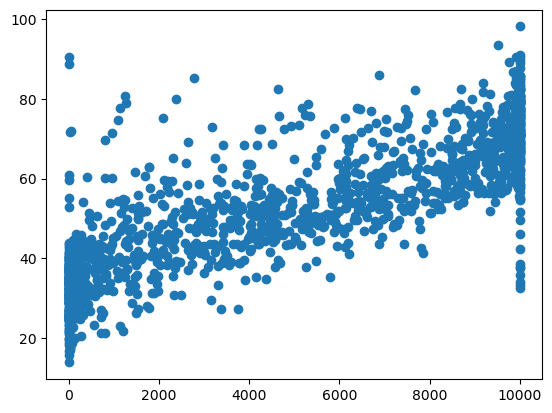

In [60]:
plt.scatter(data['dem_funds_2p_pct']**2, data['dem_pct_2p'])

In [61]:
data['dem_funds_2p_pct_sqrd'] = data['dem_funds_2p_pct']**2

## Preliminary Model Check (Frequentist OLS)

In [62]:
y = data['dem_pct_2p']
X = data[['prev_lean', 'prev2_lean', 'generic_ballot_avg',
         'dem_inc_dummy', 'rep_inc_dummy', 'dem_funds_2p_pct_sqrd']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [63]:
X.corr()

,prev_lean,prev2_lean,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_funds_2p_pct_sqrd
prev_lean,1.000000,0.978240,0.057372,0.719866,-0.689081,0.787186
prev2_lean,0.978240,1.000000,0.057328,0.721837,-0.684993,0.781953
generic_ballot_avg,0.057372,0.057328,1.000000,0.013985,-0.046466,-0.036624
dem_inc_dummy,0.719866,0.721837,0.013985,1.000000,-0.726200,0.695967
rep_inc_dummy,-0.689081,-0.684993,-0.046466,-0.726200,1.000000,-0.694456
dem_funds_2p_pct_sqrd,0.787186,0.781953,-0.036624,0.695967,-0.694456,1.000000


In [64]:
np.linalg.matrix_rank(X)

np.int64(6)

In [65]:
X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_const)
reg = model.fit(cov_type='HC1')
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             dem_pct_2p   R-squared:                       0.969
Model:                            OLS   Adj. R-squared:                  0.968
Method:                 Least Squares   F-statistic:                     7171.
Date:                Tue, 09 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:19:18   Log-Likelihood:                -2525.7
No. Observations:                1019   AIC:                             5065.
Df Residuals:                    1012   BIC:                             5100.
Df Model:                           6                                         
Covariance Type:                  HC1                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    48.3535      0.364    132.705      0.000      47.639      49.068
prev_lean                 0.6323      0.037     16.884      0.000       0.559       0.706
prev2_lean                0.2596      0.036      7.171      0.000       0.189       0.331
generic_ballot_avg       -0.3780      0.025    -15.068      0.000      -0.427      -0.329
dem_inc_dummy            -0.0490      0.375     -0.130      0.896      -0.785       0.687
rep_inc_dummy            -1.6770      0.351     -4.774      0.000      -2.366      -0.988
dem_funds_2p_pct_sqrd     0.0005   5.11e-05      8.896      0.000       0.000       0.001
==============================================================================
Omnibus:                      489.557   Durbin-Watson:                   2.060
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10303.823
Skew:                           1.703   Prob(JB):                         0.00
Kurtosis:                      18.201   Cond. No.                     2.69e+04
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
[2] The condition number is large, 2.69e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [66]:
y_test_hat = reg.predict(sm.add_constant(X_test))
X_test['residuals'] = y_test_hat - y_test
np.mean((y_test - y_test_hat)**2), np.mean(abs(y_test - y_test_hat))

(np.float64(8.6331769399086), np.float64(2.1555218716414397))

In [73]:
y_test - y_test_hat

year  district
2020  MO-03      -1.749772
2022  VA-02      -0.444288
2024  TX-23      -3.272435
      CA-33      -0.432172
2022  OH-03       0.442748
                    ...   
2024  TN-03      -0.948616
2018  TX-36      -1.116043
      TX-26       4.619136
2022  VA-06       1.218194
      MD-07       2.912839
Length: 502, dtype: float64

In [67]:
X_test.corr()

,prev_lean,prev2_lean,generic_ballot_avg,dem_inc_dummy,rep_inc_dummy,dem_funds_2p_pct_sqrd,residuals
prev_lean,1.000000,0.978461,0.121866,0.727127,-0.694030,0.784938,-0.083404
prev2_lean,0.978461,1.000000,0.114454,0.722834,-0.690766,0.776866,-0.054113
generic_ballot_avg,0.121866,0.114454,1.000000,0.086875,-0.099993,0.005100,-0.054100
dem_inc_dummy,0.727127,0.722834,0.086875,1.000000,-0.758318,0.692618,-0.164880
rep_inc_dummy,-0.694030,-0.690766,-0.099993,-0.758318,1.000000,-0.700227,0.087886
dem_funds_2p_pct_sqrd,0.784938,0.776866,0.005100,0.692618,-0.700227,1.000000,-0.092675
residuals,-0.083404,-0.054113,-0.054100,-0.164880,0.087886,-0.092675,1.000000


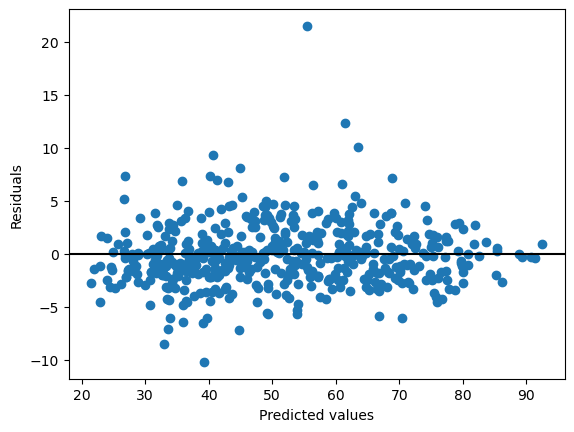

In [53]:
# Residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black')
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

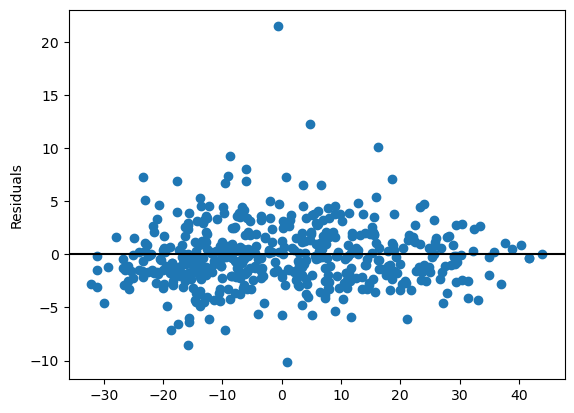

In [54]:
# Residuals
plt.scatter(X_test['prev2_lean'], y_test - y_test_hat)
plt.axhline(0, color='black')
plt.ylabel('Residuals');

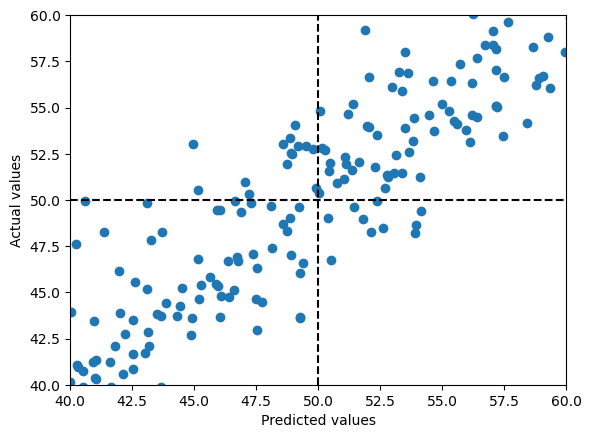

In [55]:
# Actual vs predicted
plt.scatter(y_test_hat, y_test)
plt.axhline(50, color='black', linestyle='--')
plt.axvline(50, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(40, 60)
plt.xlabel('Predicted values')
plt.ylabel('Actual values');

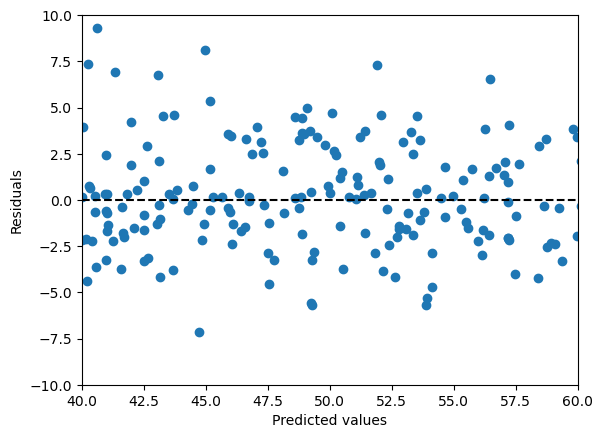

In [56]:
# Actual vs residuals
plt.scatter(y_test_hat, y_test - y_test_hat)
plt.axhline(0, color='black', linestyle='--')
plt.xlim(40, 60)
plt.ylim(-10, 10)
plt.xlabel('Predicted values')
plt.ylabel('Residuals');

In [78]:
resid = pd.DataFrame(y_test_hat - y_test)
resid = resid.reset_index().rename({0: 'resid'}, axis=1)
resid.head()

,year,district,resid
0,2020,MO-03,1.749772
1,2022,VA-02,0.444288
2,2024,TX-23,3.272435
3,2024,CA-33,0.432172
4,2022,OH-03,-0.442748


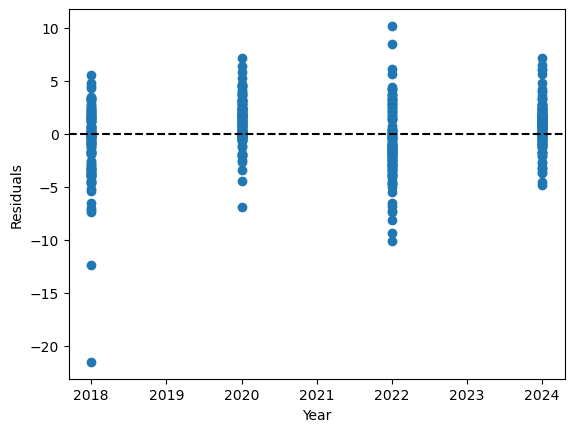

In [79]:
plt.scatter(resid['year'], resid['resid'])
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.axhline(0, color='black', linestyle='--');

In [81]:
durbin_watson(reg.resid)

np.float64(2.0599743553906857)